## Pergunta de Pesquisa

Filmes com maior bilheteria doméstica tendem a ter maior bilheteria mundial?

## Descrição dos Dados

Para responder a essa pergunta, utilizamos um dataset contendo informações financeiras sobre filmes. As principais colunas analisadas são:

- **Domestic Sales**: representa a bilheteria arrecadada no mercado doméstico.
- **International Sales**: representa a bilheteria arrecadada fora do mercado doméstico.
- **Worldwide Sales**: corresponde à soma das bilheterias doméstica e internacional, indicando o total arrecadado globalmente.
- **Domestic Opening**: refere-se à arrecadação do filme em seu fim de semana de estreia no mercado doméstico.

## Hipótese

A hipótese é que filmes com maiores valores em **Domestic Sales** tendem também a apresentar maiores valores em **Worldwide Sales**, indicando uma possível correlação positiva entre essas variáveis.

## Observações

Além disso, a coluna **Domestic Opening** pode ser utilizada para extrair insights adicionais, como o impacto da estreia no desempenho total do filme. Filmes com uma abertura forte podem ter maior visibilidade e, consequentemente, maior arrecadação ao longo do tempo.

## Objetivo

O objetivo da análise é verificar a existência e a intensidade da relação entre a bilheteria doméstica e a bilheteria mundial.

In [6]:
import pandas as pd
import seaborn as sns
from scipy.stats import pearsonr, spearmanr
import matplotlib.pyplot as plt
import kagglehub
from kagglehub import KaggleDatasetAdapter
import os

handle = "sanjeetsinghnaik/top-1000-highest-grossing-movies"
file_path = "Highest Holywood Grossing Movies.csv"

df = kagglehub.load_dataset(KaggleDatasetAdapter.PANDAS, handle, file_path)

list(df.columns)


C:\Users\mirci\AppData\Local\Temp\ipykernel_19388\1179833260.py:12: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(KaggleDatasetAdapter.PANDAS, handle, file_path)


['Unnamed: 0',
 'Title',
 'Movie Info',
 'Year',
 'Distributor',
 'Budget (in $)',
 'Domestic Opening (in $)',
 'Domestic Sales (in $)',
 'International Sales (in $)',
 'World Wide Sales (in $)',
 'Release Date',
 'Genre',
 'Running Time',
 'License']

## Verificação de Dados Faltantes

Antes de iniciar a análise, é importante verificar se existem dados faltantes nas colunas utilizadas:

- **Domestic Sales**
- **International Sales**
- **Worldwide Sales**
- **Domestic Opening**

A presença de valores nulos pode impactar os resultados da análise, por isso essa etapa é necessária para garantir a qualidade dos dados.

In [8]:
df_filtrado = df[['Title','Domestic Sales (in $)','International Sales (in $)','World Wide Sales (in $)','Domestic Opening (in $)']]

df_filtrado.dtypes


Title                           str
Domestic Sales (in $)         int64
International Sales (in $)    int64
World Wide Sales (in $)       int64
Domestic Opening (in $)         str
dtype: object

É possivel notar que Domestic Opening esta no formato string então é preciso converte ele para um formato de inteiro como as estão nas demais colunas !

In [9]:
print(df_filtrado['Domestic Opening (in $)'])

0       77025481
1      357115007
2      134100226
3       28638131
4      247966675
         ...    
995     35648740
996     29651193
997     15190758
998     20574802
999     30429860
Name: Domestic Opening (in $), Length: 1000, dtype: str


In [12]:
(~df_filtrado['Domestic Opening (in $)'].str.match(r'^[\d\$,]+$')).any()


np.True_

** Aparti dessa analise de regex é possivel notar que existe colunas em Domectic Opeing que contem caracteres diferentes de numeros, o que indica possíveis problemas.

In [ ]:
df.loc[~df['Domestic Opening (in $)'].str.match(r'^[\d\$,]+$'),['Title', 'Domestic Opening (in $)']]

,Title,Domestic Opening (in $)
95,"Hi, Mom",2 hr 8 min
148,Detective Chinatown 3,February 12 2021 (China)
279,Moon Man,2 hr 2 min
285,Dying to Survive,1 hr 57 min
317,"My People, My Homeland",2 hr 33 min
344,Gone with the Wind,December 15 1939 (Domestic)
401,Hello Mr. Billionaire,1 hr 58 min
467,Never Say Die,1 hr 40 min
482,Crazy Alien,1 hr 56 min
615,Bambi,August 21 1942 (Domestic)


In [17]:
df.loc[~df['Domestic Opening (in $)'].str.match(r'^[\d\$,]+$'),['Title', 'Domestic Opening (in $)']].shape[0]

28

## Tratamento de Valores Inconsistentes

A partir da análise utilizando expressões regulares (regex), foi identificado que a coluna **Domestic Opening (in $)** contém valores que não seguem o padrão esperado de dados numéricos.

Foram encontrados **28 registros** com valores inconsistentes, incluindo informações como tempo de duração do filme (ex: "2 hr 8 min") e datas de lançamento, o que indica um erro ou inconsistência no dataset.

Esses valores não são relevantes para a análise proposta e podem comprometer os resultados estatísticos.

## Decisão de Tratamento

Dado que a quantidade de registros inválidos é relativamente pequena em relação ao total de dados, a estratégia adotada será a **remoção dessas linhas** do DataFrame.

Essa abordagem garante que a análise seja realizada apenas com dados válidos e confiáveis, sem introduzir distorções nos resultados.

In [ ]:
df_filtrado = df_filtrado[df_filtrado['Domestic Opening (in $)'].str.match(r'^[\d\$,]+$')]

(~df_filtrado['Domestic Opening (in $)'].str.match(r'^[\d\$,]+$')).any()

np.False_

In [20]:
print("Antes:", df.shape[0])
print("Depois:", df_filtrado.shape[0])

Antes: 1000
Depois: 972


## Remoção de Dados Inconsistentes

Após a identificação de valores inconsistentes na coluna **Domestic Opening (in $)**, foi realizada a remoção dessas entradas do DataFrame.

A remoção desses registros garante que o conjunto de dados utilizado seja composto apenas por valores válidos e adequados para análise.

In [21]:
df_filtrado['Domestic Opening (in $)'] = df_filtrado['Domestic Opening (in $)'].astype('int64')

df_filtrado.dtypes

Title                           str
Domestic Sales (in $)         int64
International Sales (in $)    int64
World Wide Sales (in $)       int64
Domestic Opening (in $)       int64
dtype: object

In [28]:
cols = ['Domestic Sales (in $)','International Sales (in $)','World Wide Sales (in $)','Domestic Opening (in $)']
(df_filtrado[cols] < 0).any()

Domestic Sales (in $)         False
International Sales (in $)    False
World Wide Sales (in $)       False
Domestic Opening (in $)       False
dtype: bool

## Verificação de Valores Negativos

Foi realizada a verificação de valores negativos nas principais colunas numéricas do dataset.

Não foram encontrados valores negativos, portanto não foi necessário realizar tratamento adicional.

In [32]:
df_filtrado.describe()

,Domestic Sales (in $),International Sales (in $),World Wide Sales (in $),Domestic Opening (in $)
count,9.720000e+02,9.720000e+02,9.720000e+02,9.720000e+02
mean,1.622744e+08,2.639542e+08,4.264058e+08,4.269505e+07
std,1.169126e+08,2.145428e+08,3.080309e+08,3.926199e+07
min,1.805800e+04,2.450000e+07,1.799689e+08,7.456000e+03
25%,9.464145e+07,1.310459e+08,2.280909e+08,1.997578e+07
50%,1.328338e+08,1.932899e+08,3.215637e+08,3.279074e+07
75%,1.937921e+08,3.162972e+08,4.909723e+08,5.458932e+07
max,9.366622e+08,2.138484e+09,2.923706e+09,3.571150e+08


<Axes: >

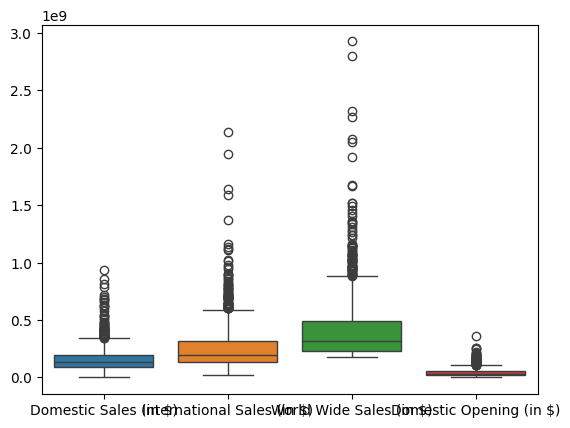

In [33]:
import seaborn as sns
sns.boxplot(data=df_filtrado)